# Jharkhand School Dropout Analysis
### Kajal Kumari | UDISE+ 2024-25 | 24 Districts

**Research Questions:**
1. Which districts have the highest school dropout rates?
2. What structural factors (PTR, infrastructure) drive dropout?
3. Which districts need the most urgent policy intervention?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F8F6',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

CORAL  = '#D85A30'
TEAL   = '#1D9E75'
AMBER  = '#BA7517'
PURPLE = '#7F77DD'
GRAY   = '#888780'

# Load data
df = pd.read_csv('jharkhand_master_data.csv')

# Clean district names
df['District'] = df['District'].str.replace(r'\nD$', '', regex=True).str.strip()

print(f'Loaded: {df.shape[0]} districts x {df.shape[1]} columns')
print(f'Districts: {sorted(df.District.tolist())}')

Loaded: 24 districts x 37 columns
Districts: ['Bokaro', 'Chatra', 'Deoghar', 'Dhanbad', 'Dumka', 'Garhwa', 'Giridih', 'Godda', 'Gumla', 'Hazaribag', 'Jamtara', 'Khunti', 'Kodarma', 'Latehar', 'Lohardaga', 'Pakaur', 'Palamu', 'Pashchimi Singhbhum', 'Purbi Singhbhum', 'Ramgarh', 'Ranchi', 'Sahibganj', 'Saraikela-Kharsawan', 'Simdega']


## Section 1 — Data Quality Check

In [3]:
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('No missing values in key columns.')
else:
    print(missing)

print('\n=== KEY COLUMNS SUMMARY ===')
key = ['Dropout_Middle','Dropout_Secondary','PTR_Secondary','PTR_Middle',
       'Trans_Mid_to_Sec','Hidden_Dropout_Mid_to_Sec_Pct','ST_Proportion_Pct','PGI_Score']
print(df[key].describe().round(2))

print('\n=== STATE AVERAGE BENCHMARKS ===')
print(f"Avg Hidden Dropout (Mid->Sec): {df['Hidden_Dropout_Mid_to_Sec_Pct'].mean():.1f}%")
print(f"Avg PTR Secondary:             {df['PTR_Secondary'].mean():.1f}")
print(f"Avg Dropout Middle:            {df['Dropout_Middle'].mean():.1f}%")
print(f"Avg PGI Score:                 {df['PGI_Score'].mean():.1f}")

=== MISSING VALUES ===
GER_Foundational    24
GER_Preparatory     24
GER_Middle          24
Pct_Girls_Toilet    24
Pct_Playground      24
dtype: int64

=== KEY COLUMNS SUMMARY ===
       Dropout_Middle  Dropout_Secondary  PTR_Secondary  PTR_Middle  \
count           24.00              24.00          24.00       24.00   
mean             2.86               2.74          43.33       25.79   
std              2.78               3.77          12.47        8.37   
min              0.00               0.00          26.00       16.00   
25%              0.00               0.00          36.50       18.75   
50%              2.60               1.25          40.50       23.50   
75%              3.92               4.58          51.00       32.50   
max             11.00              15.90          69.00       42.00   

       Trans_Mid_to_Sec  Hidden_Dropout_Mid_to_Sec_Pct  ST_Proportion_Pct  \
count             24.00                          24.00              24.00   
mean              80.26   

## Section 2 — District Rankings: Who Is Worst?

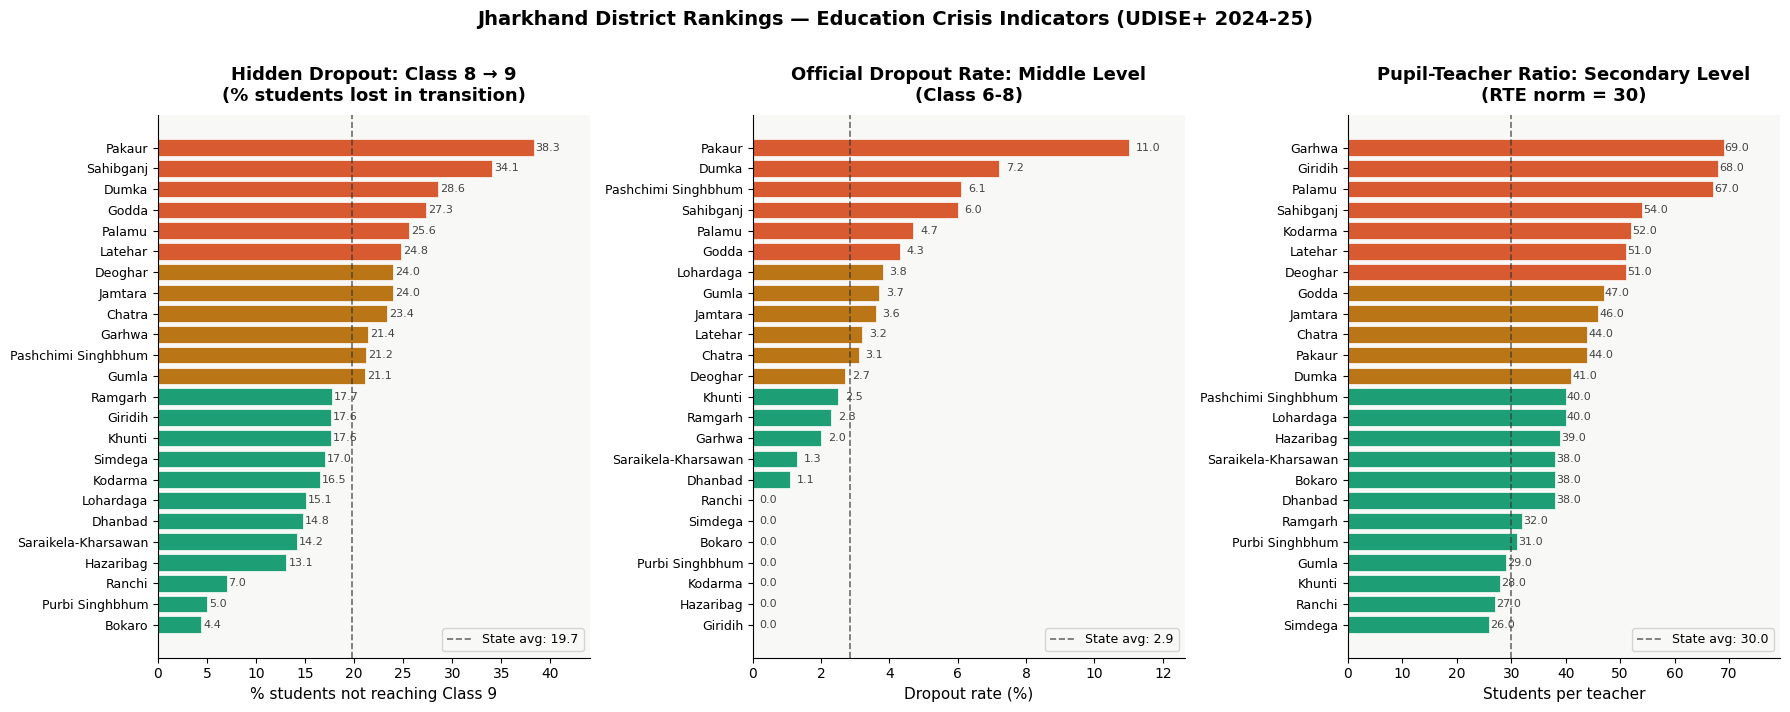

Saved: chart1_district_rankings.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Jharkhand District Rankings — Education Crisis Indicators (UDISE+ 2024-25)',
             fontsize=14, fontweight='bold', y=1.01)

def bar_chart(ax, col, title, xlabel, color, state_avg=None):
    data = df[['District', col]].sort_values(col, ascending=True)
    colors = [CORAL if v >= data[col].quantile(0.75) else
              AMBER if v >= data[col].median() else TEAL
              for v in data[col]]
    bars = ax.barh(data['District'], data[col], color=colors, edgecolor='white', linewidth=0.5)
    if state_avg:
        ax.axvline(state_avg, color='#333', linewidth=1.2, linestyle='--', alpha=0.7,
                   label=f'State avg: {state_avg:.1f}')
        ax.legend(fontsize=9)
    for bar, val in zip(bars, data[col]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=8, color='#444')
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xlim(0, data[col].max() * 1.15)

bar_chart(axes[0], 'Hidden_Dropout_Mid_to_Sec_Pct',
          'Hidden Dropout: Class 8 → 9\n(% students lost in transition)',
          '% students not reaching Class 9', CORAL,
          state_avg=df['Hidden_Dropout_Mid_to_Sec_Pct'].mean())

bar_chart(axes[1], 'Dropout_Middle',
          'Official Dropout Rate: Middle Level\n(Class 6-8)',
          'Dropout rate (%)', AMBER,
          state_avg=df['Dropout_Middle'].mean())

bar_chart(axes[2], 'PTR_Secondary',
          'Pupil-Teacher Ratio: Secondary Level\n(RTE norm = 30)',
          'Students per teacher', CORAL,
          state_avg=30)

plt.tight_layout()
plt.savefig('chart1_district_rankings.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart1_district_rankings.png')

## Section 3 — Correlation Analysis: What Drives Dropout?

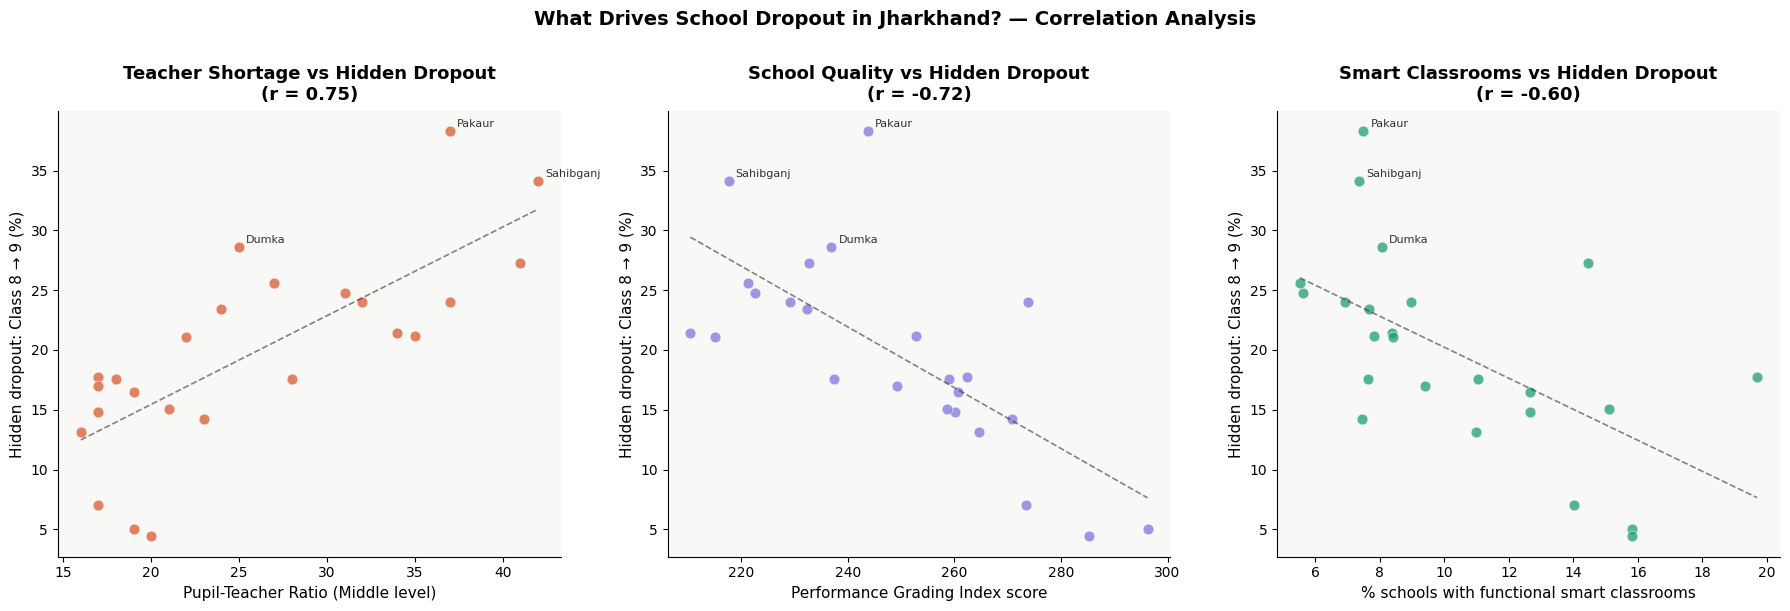

Saved: chart2_correlations.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('What Drives School Dropout in Jharkhand? — Correlation Analysis',
             fontsize=14, fontweight='bold', y=1.01)

def scatter(ax, x_col, y_col, title, xlabel, ylabel, color):
    ax.scatter(df[x_col], df[y_col], color=color, alpha=0.75, s=60, edgecolors='white', linewidth=0.5)
    # Trend line
    z = df[[x_col, y_col]].dropna()
    m, b = pd.np.polyfit(z[x_col], z[y_col], 1) if hasattr(pd, 'np') else __import__('numpy').polyfit(z[x_col], z[y_col], 1)
    x_line = pd.Series([z[x_col].min(), z[x_col].max()])
    ax.plot(x_line, m * x_line + b, color='#333', linewidth=1.2, linestyle='--', alpha=0.6)
    # Label worst districts
    worst = df.nlargest(3, y_col)
    for _, row in worst.iterrows():
        ax.annotate(row['District'], (row[x_col], row[y_col]),
                    textcoords='offset points', xytext=(5, 3), fontsize=8, color='#333')
    corr = df[[x_col, y_col]].corr().iloc[0,1]
    ax.set_title(f'{title}\n(r = {corr:.2f})', pad=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

import numpy as np

def scatter2(ax, x_col, y_col, title, xlabel, ylabel, color):
    valid = df[[x_col, y_col]].dropna()
    ax.scatter(valid[x_col], valid[y_col], color=color, alpha=0.75, s=60,
               edgecolors='white', linewidth=0.5)
    m, b = np.polyfit(valid[x_col], valid[y_col], 1)
    x_line = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='#333', linewidth=1.2, linestyle='--', alpha=0.6)
    worst = df.nlargest(3, y_col)[['District', x_col, y_col]]
    for _, row in worst.iterrows():
        ax.annotate(row['District'], (row[x_col], row[y_col]),
                    textcoords='offset points', xytext=(5, 3), fontsize=8, color='#333')
    corr = valid.corr().iloc[0,1]
    ax.set_title(f'{title}\n(r = {corr:.2f})', pad=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

scatter2(axes[0], 'PTR_Middle', 'Hidden_Dropout_Mid_to_Sec_Pct',
         'Teacher Shortage vs Hidden Dropout',
         'Pupil-Teacher Ratio (Middle level)',
         'Hidden dropout: Class 8 → 9 (%)', CORAL)

scatter2(axes[1], 'PGI_Score', 'Hidden_Dropout_Mid_to_Sec_Pct',
         'School Quality vs Hidden Dropout',
         'Performance Grading Index score',
         'Hidden dropout: Class 8 → 9 (%)', PURPLE)

scatter2(axes[2], 'Pct_Smart_Classrooms', 'Hidden_Dropout_Mid_to_Sec_Pct',
         'Smart Classrooms vs Hidden Dropout',
         '% schools with functional smart classrooms',
         'Hidden dropout: Class 8 → 9 (%)', TEAL)

plt.tight_layout()
plt.savefig('chart2_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart2_correlations.png')

## Section 4 — Infrastructure Gap Analysis

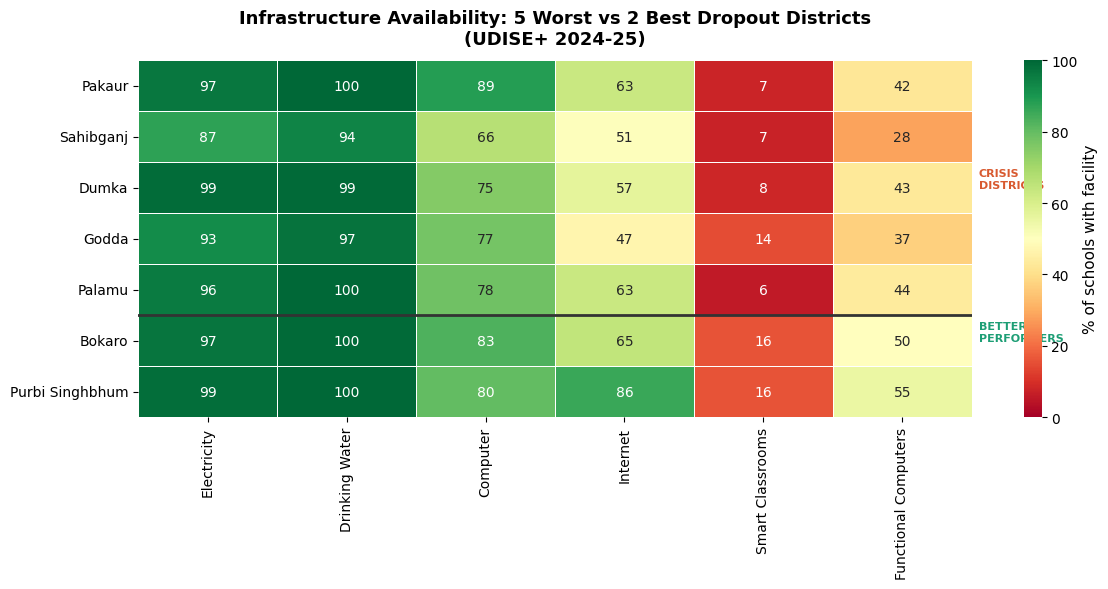

Saved: chart3_infrastructure_heatmap.png


In [6]:
infra_cols = ['Pct_Electricity','Pct_Drinking_Water','Pct_Computer',
              'Pct_Internet','Pct_Smart_Classrooms','Pct_Functional_Computer']
infra_labels = ['Electricity','Drinking Water','Computer','Internet',
                'Smart Classrooms','Functional Computers']

# Focus on 5 worst dropout districts + 2 best for comparison
worst5 = df.nlargest(5, 'Hidden_Dropout_Mid_to_Sec_Pct')['District'].tolist()
best2  = df.nsmallest(2, 'Hidden_Dropout_Mid_to_Sec_Pct')['District'].tolist()
focus  = worst5 + best2

heat_df = df[df['District'].isin(focus)].set_index('District')[infra_cols]
heat_df.columns = infra_labels
heat_df = heat_df.loc[focus]  # keep order

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heat_df, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% of schools with facility'})
ax.set_title('Infrastructure Availability: 5 Worst vs 2 Best Dropout Districts\n(UDISE+ 2024-25)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10)

# Add separator line between worst and best
ax.axhline(5, color='#333', linewidth=2)
ax.text(6.05, 2.5, 'CRISIS\nDISTRICTS', fontsize=8, color=CORAL, fontweight='bold')
ax.text(6.05, 5.5, 'BETTER\nPERFORMERS', fontsize=8, color=TEAL, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_infrastructure_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart3_infrastructure_heatmap.png')

## Section 5 — Data Story & Key Findings

In [7]:
worst  = df.loc[df['Hidden_Dropout_Mid_to_Sec_Pct'].idxmax()]
best   = df.loc[df['Hidden_Dropout_Mid_to_Sec_Pct'].idxmin()]
avg_hd = df['Hidden_Dropout_Mid_to_Sec_Pct'].mean()
avg_ptr= df['PTR_Secondary'].mean()
corr_ptr = df[['PTR_Middle','Hidden_Dropout_Mid_to_Sec_Pct']].corr().iloc[0,1]
corr_pgi = df[['PGI_Score','Hidden_Dropout_Mid_to_Sec_Pct']].corr().iloc[0,1]

story = f"""
============================================================
DATA STORY — JHARKHAND SCHOOL DROPOUT ANALYSIS
Kajal Kumari | UDISE+ 2024-25
============================================================

HEADLINE FINDING:
Jharkhand's official dropout statistics significantly undercount
the true scale of the education crisis. While reported dropout rates
appear modest, transition rate data reveals that on average {avg_hd:.1f}%
of students who complete Class 8 never reach Class 9 — silently
disappearing from the system without being counted as dropouts.

CRISIS DISTRICTS:
- {worst['District']} is the worst-affected district: {worst['Hidden_Dropout_Mid_to_Sec_Pct']:.1f}%
  of students are lost at the Class 8→9 transition.
- The top 5 crisis districts (Pakaur, Sahibganj, Dumka, Godda, Palamu)
  all lose more than 25% of students at this critical juncture.
- {best['District']} performs best with only {best['Hidden_Dropout_Mid_to_Sec_Pct']:.1f}%
  hidden dropout — showing that the crisis is not inevitable.

ROOT CAUSE — TEACHER SHORTAGE:
- PTR at Middle level has the strongest correlation with dropout (r = {corr_ptr:.2f}).
- The state average PTR at Secondary level is {avg_ptr:.0f} — well above the
  RTE norm of 30. Garhwa (69), Giridih (68), and Palamu (67) are the worst.
- Districts with fewer teachers consistently lose more students.

SCHOOL QUALITY IS THE REAL DIVIDER:
- PGI Score (overall school quality index) has a strong negative
  correlation with dropout (r = {corr_pgi:.2f}): better schools retain more children.
- Smart classroom availability also strongly predicts retention (r = -0.60).
- Tribal (ST) proportion has almost zero correlation (r = 0.03) with dropout —
  children leave because of poor schools, not because of who they are.

POLICY RECOMMENDATION:
1. Priority teacher hiring in Pakaur, Sahibganj, Garhwa, Giridih, Palamu.
2. Smart classroom expansion in the 5 crisis districts.
3. Transition monitoring: track Class 8→9 movement, not just annual dropout rates.
============================================================
"""
print(story)

# Save as text file too
with open('data_story.txt', 'w') as f:
    f.write(story)
print('Saved: data_story.txt')


DATA STORY — JHARKHAND SCHOOL DROPOUT ANALYSIS
Kajal Kumari | UDISE+ 2024-25

HEADLINE FINDING:
Jharkhand's official dropout statistics significantly undercount
the true scale of the education crisis. While reported dropout rates
appear modest, transition rate data reveals that on average 19.7%
of students who complete Class 8 never reach Class 9 — silently
disappearing from the system without being counted as dropouts.

CRISIS DISTRICTS:
- Pakaur is the worst-affected district: 38.3%
  of students are lost at the Class 8→9 transition.
- The top 5 crisis districts (Pakaur, Sahibganj, Dumka, Godda, Palamu)
  all lose more than 25% of students at this critical juncture.
- Bokaro performs best with only 4.4%
  hidden dropout — showing that the crisis is not inevitable.

ROOT CAUSE — TEACHER SHORTAGE:
- PTR at Middle level has the strongest correlation with dropout (r = 0.75).
- The state average PTR at Secondary level is 43 — well above the
  RTE norm of 30. Garhwa (69), Giridih (68), an

UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 665: character maps to <undefined>